In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict


from sandbox.jordan8 import *

import json
import os

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [3]:
model = JordanNet(encode_dim=32)
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.eval()


C:\Users\micha\AppData\Local\Temp\ipykernel_15288\489443331.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_modi

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [42]:
d=15
superdiag = get_superdiagonal(8, d)
J = np.diag(superdiag, k=1)

A = (np.eye(d) + J) @ np.linalg.inv(np.eye(d) - J) - np.eye(d)
# S = np.diag(np.random.uniform(0, 1, size=d)) + np.diag(np.random.uniform(0, 1, size=d-1), k=1) + np.diag(np.random.uniform(0, 1, size=d-1), k=-1)
S = np.random.randn(d,d)
print(np.linalg.cond(S))

E = np.random.randn(d,d)/np.sqrt(d)

matrices = []
features = []
epsilons = [0, 1e-4, 1e-3, 1e-2, 1e-1, 0.5]
for eps in epsilons:
    J_0 = (J + eps*E)
    radius = np.max(np.abs(np.linalg.eigvals(J_0)))
    if radius > 1:
        J_0 /= radius
    A_0 = np.linalg.inv(S) @ J_0 @ S
    matrices.append(A_0)
    features.append(per_power_features(A_0))

matrices = torch.tensor(matrices, dtype=torch.float32)
features = torch.tensor(features, dtype=torch.float32)

1253.9138556758417


In [43]:
logits = model(d, features)
probs = torch.softmax(logits, dim=-1)
probs = probs.detach().cpu().numpy()


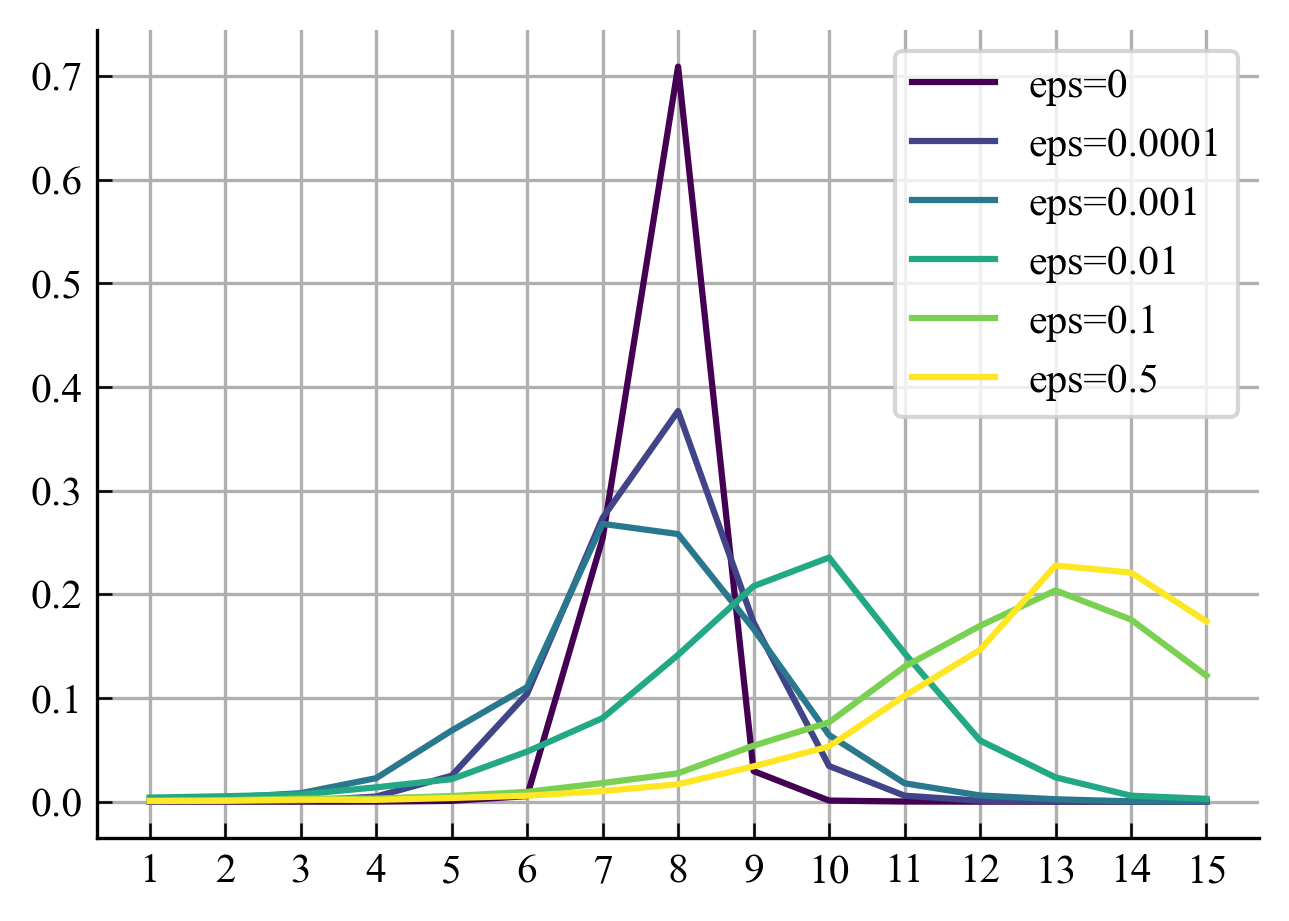

In [44]:
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0, 1, len(epsilons)))
for i, eps in enumerate(epsilons):
    plt.plot(probs[i], label=f"eps={eps}", color=colors[i])

plt.legend()
plt.xticks(ticks=range(d), labels=range(1, d+1))
plt.grid()
plt.show()

[[ 0.00000000e+00 -1.08704412e-16 -2.92935604e-16  2.35730828e-15
  -3.64301836e-15 -9.83095626e-18  2.89735948e-15 -6.15710855e-15
   2.23068301e-15 -2.25141396e-15 -3.43632520e-15 -3.92174454e-15
  -2.33721231e-14 -6.42506526e-15 -4.02927988e-19 -1.13143498e-20
   3.00268530e-19 -9.04931613e-19  9.57417325e-20  6.41328803e-19
  -2.21021118e-19  1.19686142e-19  1.86233350e-19  1.79203845e-19
  -8.28909980e-19 -1.04054400e-18 -2.90704676e-20  2.08511349e-18]
 [-9.83605154e-17  0.00000000e+00 -5.77271535e-16 -1.88253296e-15
   1.74860168e-16 -4.45576730e-15 -3.12382355e-15  5.02284265e-16
  -1.58971300e-14 -3.09072848e-15  7.32779952e-15 -1.20610501e-14
  -5.14933373e-15  1.59645182e-14 -7.58941521e-19 -4.33680869e-19
   1.08420217e-19 -1.08420217e-18  2.16840434e-19 -2.16840434e-18
   4.33680869e-19 -1.08420217e-19 -3.25260652e-19  1.08420217e-19
  -5.42101086e-19 -6.77626358e-19 -2.16840434e-19 -1.62630326e-19]
 [ 4.81858964e-17 -5.94771669e-16  1.33226763e-15  2.13828547e-15
  -2.051

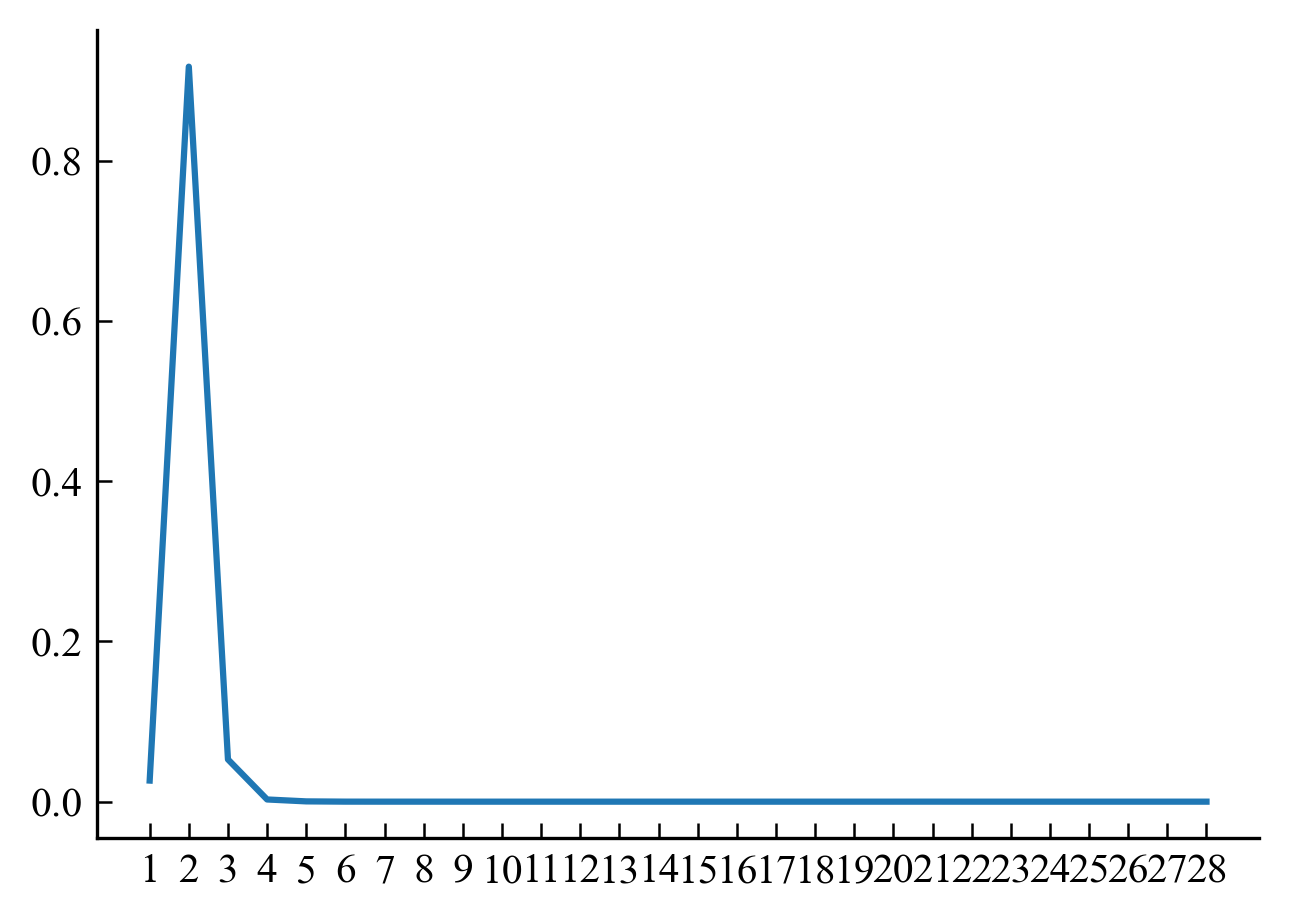

In [8]:
d=28
superdiag = get_superdiagonal(8, d)
J = np.diag(superdiag, k=1)

E = np.zeros((d,d))
E[:d//2, :d//2] = np.diag(np.arange(d//2))

A = np.zeros((d,d))
X = np.random.randn(d//2,d//2)
A[:d//2, d//2:] = X
A[d//2:, :d//2] = -X.T

h = 1e-3
A_0 = np.linalg.solve(E - h*A, E + h * A) + np.eye(d) # + 1e-6 * np.random.randn(d,d)/np.sqrt(d)

print(A_0)

features = [per_power_features(A_0)]
features = torch.tensor(features, dtype=torch.float32)
logits = model(d, features)
probs = torch.softmax(logits, dim=-1)

plt.plot(probs.detach().numpy()[0])

plt.xticks(ticks=range(d), labels=range(1, d+1))

plt.show()

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  5.64473544e+02 -4.85790722e+03 -1.93870877e+03
  -1.24030903e+04  1.13542896e+04 -4.52634534e+07  2.72235212e+07
   3.43409185e+07  1.44221474e+08  1.04628112e+07]
 [-8.82365688e-18  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -4.21368886e+01 -2.00752494e+03 -1.29382344e+03
  -6.50243340e+03  6.02369880e+03 -1.95035899e+07  1.19953271e+07
   1.66265621e+07  6.07343748e+07  3.55963985e+06]
 [ 1.24862294e-17 -5.52350288e-17  0.00000000e+00  0.00000000e+00
   0.00000000e+00  9.36340850e+02 -1.02749203e+03  8.30284407e+01
  -1.88605102e+03  2.90763468e+03 -2.01061719e+06  2.38598943e+06
   4.98898915e+06 -1.06963049e+06 -4.45096235e+05]
 [-1.42774694e-17 -3.42769792e-17  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.14427570e+03 -7.99154047e+02  5.34549263e+00
  -2.21763408e+03  1.52860702e+03  2.04008969e+06 -1.28985824e+06
   1.04717872e+06 -1.39766863e+07 -1.59534452e+06]
 [ 0

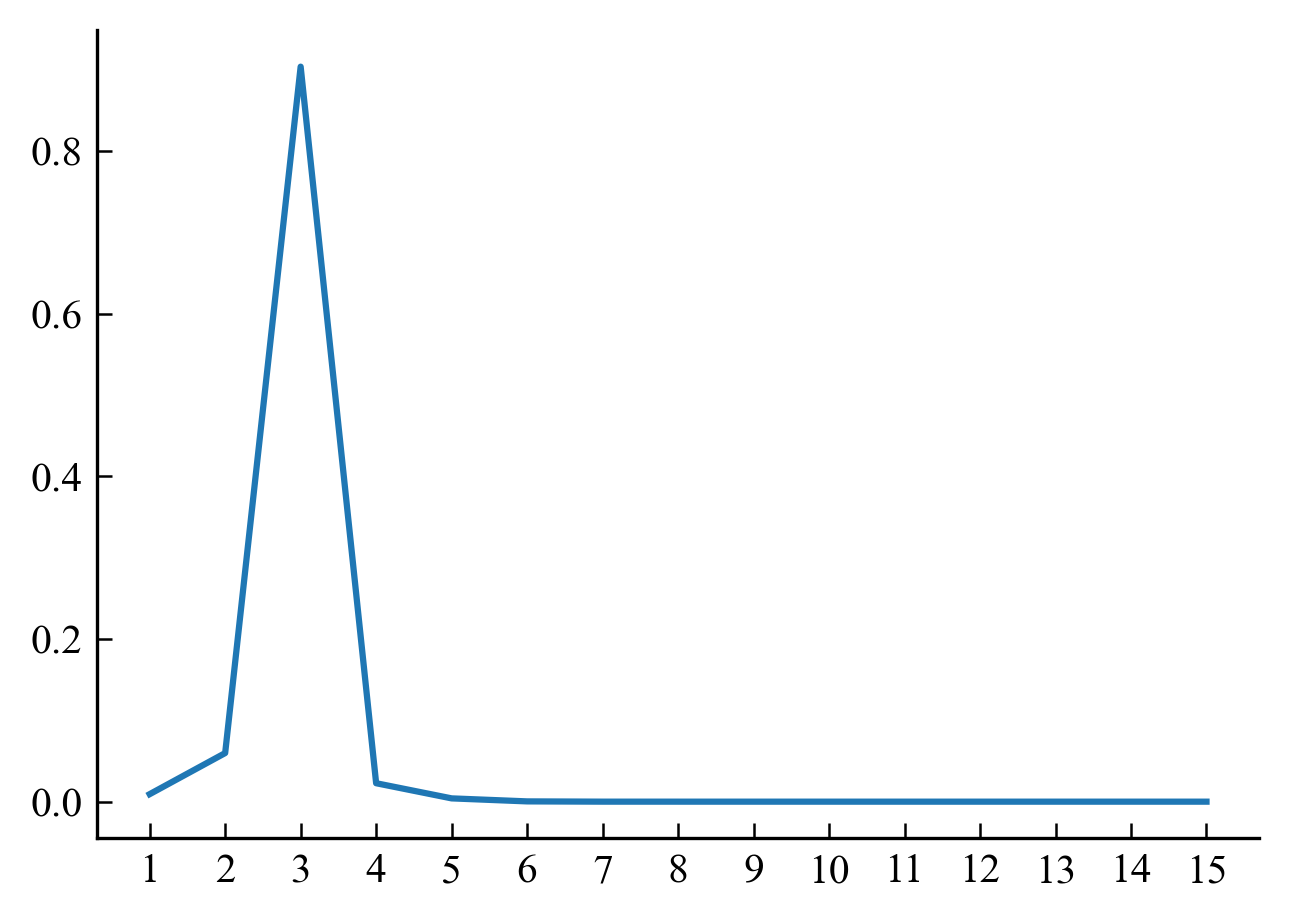

In [9]:
d=15
superdiag = get_superdiagonal(8, d)
J = np.diag(superdiag, k=1)

E = np.zeros((d,d))
E[:5,5:10] = np.random.randn(5,5)/np.sqrt(5)
E[5:10, 10:] = np.random.randn(5,5)/np.sqrt(5)

A = np.zeros((d,d))
A[:5, :5] = np.random.randn(5,5)/np.sqrt(5)
A[5:10, 5:10] = np.random.randn(5,5)/np.sqrt(5)
A[10:, 10:] = np.random.randn(5,5)/np.sqrt(5)


h = 1e-3
A_0 = np.linalg.solve(E - h*A, E + h * A) + np.eye(d) # + 1e-6 * np.random.randn(d,d)/np.sqrt(d)

print(A_0)

features = [per_power_features(A_0)]
features = torch.tensor(features, dtype=torch.float32)
logits = model(d, features)
probs = torch.softmax(logits, dim=-1)

plt.plot(probs.detach().numpy()[0])

plt.xticks(ticks=range(d), labels=range(1, d+1))

plt.show()

In [10]:
print(A_0)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  5.64473544e+02 -4.85790722e+03 -1.93870877e+03
  -1.24030903e+04  1.13542896e+04 -4.52634534e+07  2.72235212e+07
   3.43409185e+07  1.44221474e+08  1.04628112e+07]
 [-8.82365688e-18  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -4.21368886e+01 -2.00752494e+03 -1.29382344e+03
  -6.50243340e+03  6.02369880e+03 -1.95035899e+07  1.19953271e+07
   1.66265621e+07  6.07343748e+07  3.55963985e+06]
 [ 1.24862294e-17 -5.52350288e-17  0.00000000e+00  0.00000000e+00
   0.00000000e+00  9.36340850e+02 -1.02749203e+03  8.30284407e+01
  -1.88605102e+03  2.90763468e+03 -2.01061719e+06  2.38598943e+06
   4.98898915e+06 -1.06963049e+06 -4.45096235e+05]
 [-1.42774694e-17 -3.42769792e-17  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.14427570e+03 -7.99154047e+02  5.34549263e+00
  -2.21763408e+03  1.52860702e+03  2.04008969e+06 -1.28985824e+06
   1.04717872e+06 -1.39766863e+07 -1.59534452e+06]
 [ 0

In [11]:
N = 100
dtype = torch.float32
epsilons = [0] #+ [0.001, 0.05, 0.1, 0.3, 0.5, 0.7, 1.]

d = 15  # define once, before using it
probs = torch.zeros(6, d)
counts = torch.zeros(6)  # <-- track valid samples
ms = [2, 3, 6, 8, 12, 15]

A_0_norm = 0
E_norm = 0

for i in range(N):
    for j, m in enumerate(ms):
        superdiag = get_superdiagonal(m, d)
        J = np.diag(superdiag, k=1)
        S = np.random.randn(d, d)
        E = np.random.randn(d, d)
        A_0 = np.linalg.inv(S) @ J @ S
        A_0 /= np.linalg.norm(A_0)

        A_0_norm += np.linalg.norm(A_0)
        E_norm += np.linalg.norm(E)

        matrices = []
        features = []
        # for j, eps in enumerate(epsilons):
        A = A_0
        # A /= np.linalg.norm(A)
        matrices.append(A)
        features.append(per_power_features(A))

        matrices = torch.tensor(matrices, dtype=dtype)
        features = torch.tensor(features, dtype=dtype)

        logits = model(d, features)
        curr_probs = torch.softmax(logits, dim=-1)

        for curr_prob in curr_probs:
            if not torch.isnan(curr_prob).any():
                probs[j] += curr_prob
                counts[j] += 1  # <-- increment only when valid


# avoid division by zero
counts = counts.clamp(min=1)

probs = probs / counts.unsqueeze(1)

print(A_0_norm/(N*len(ms)))
print(E_norm/(N*len(ms)))

1.0
14.977355495004273


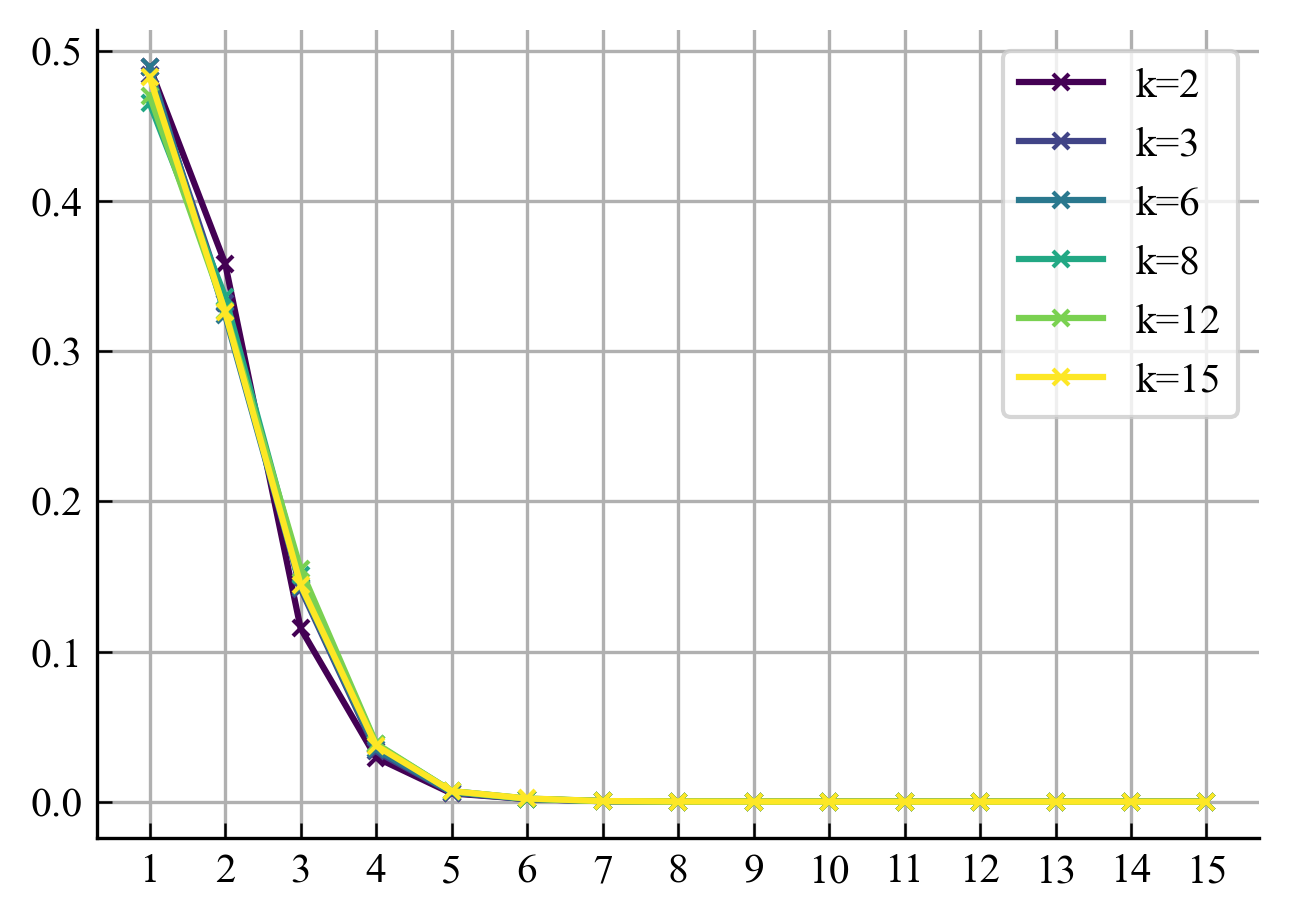

In [12]:
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0, 1, len(ms)))
for j, m in enumerate(ms):
    plt.plot(probs[j,].detach(), marker='x', color=colors[j], label=f"k={m}")

plt.legend()
plt.grid()
plt.xticks(ticks=range(d), labels=range(1, d+1))
plt.show()

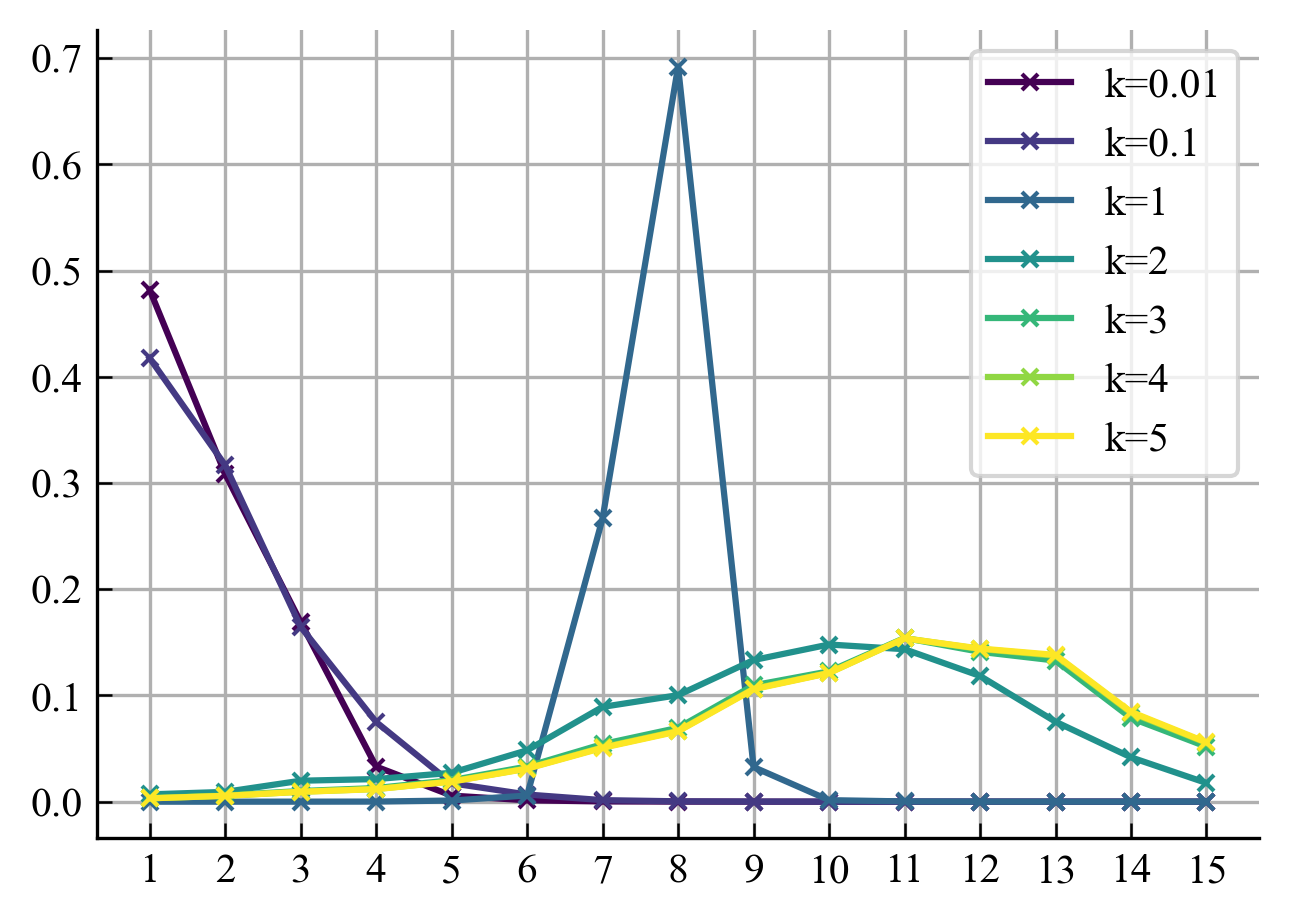

In [13]:
N = 100
dtype = torch.float32
epsilons = [0] + [0.001, 0.05, 0.1, 0.3, 0.5, 0.7, 1.]
ks = [1e-2, 1e-1, 1, 2, 3, 4, 5]

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0, 1, len(ks)))

d = 15  # define once, before using it

# A_0_norm = 0
# E_norm = 0
superdiag = get_superdiagonal(8, d)
J = np.diag(superdiag, k=1)
S = np.random.randn(d, d)
E = np.random.randn(d, d)
A_0 = np.linalg.inv(S) @ J @ S

eps = 1e-4

for j, k in enumerate(ks):
    matrices = []
    features = []
    # for j, eps in enumerate(epsilons):
    A = np.linalg.inv(S) @ (k*J + eps*E) @ S
    matrices.append(A)
    features.append(per_power_features(A))

    matrices = torch.tensor(matrices, dtype=dtype)
    features = torch.tensor(features, dtype=dtype)

    logits = model(d, features)
    curr_probs = torch.softmax(logits, dim=-1)

    plt.plot(curr_probs.detach()[0], marker='x', color=colors[j], label=f"k={k}")

plt.legend()
plt.grid()
plt.xticks(ticks=range(d), labels=range(1, d+1))
plt.show()

[]

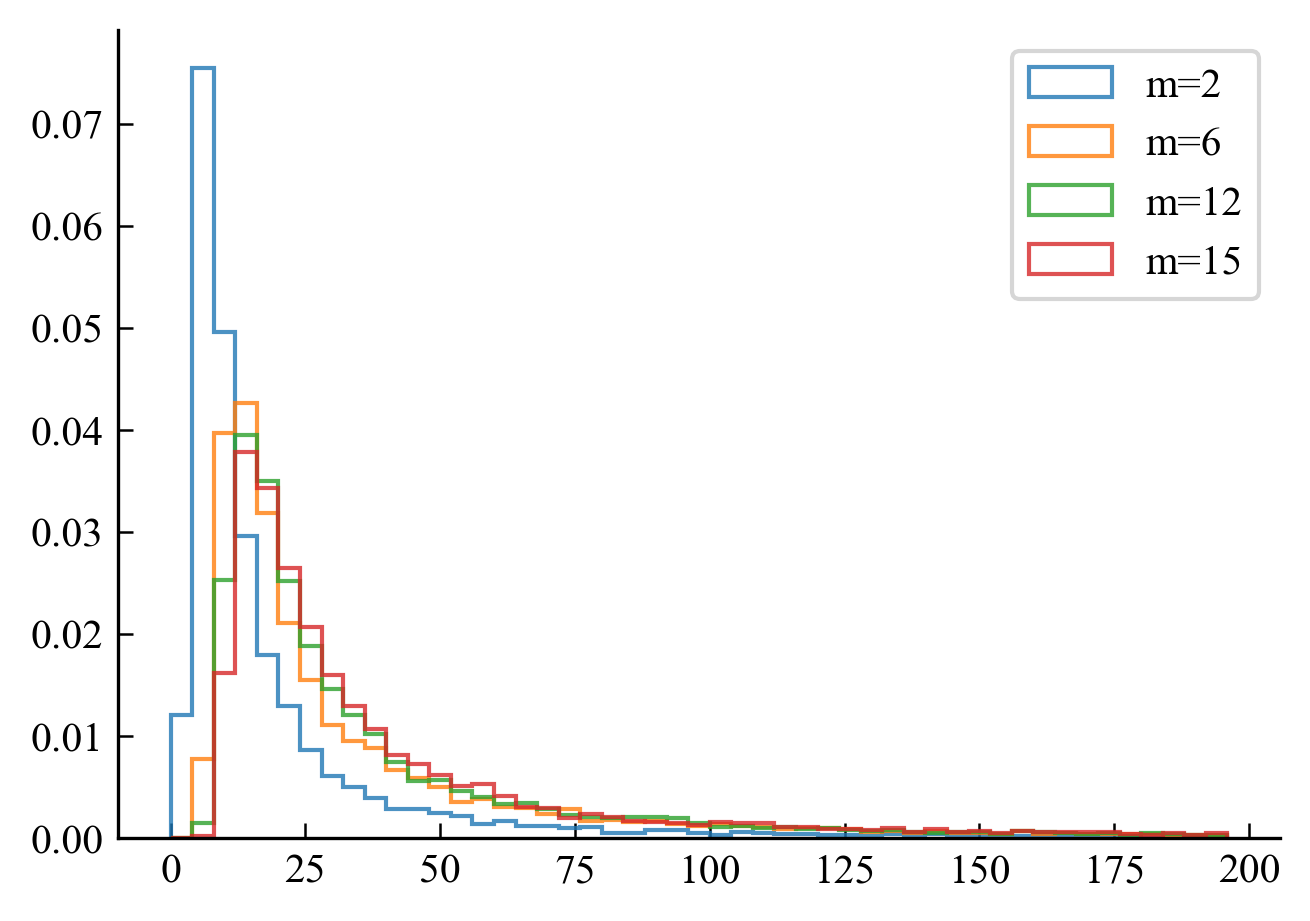

In [14]:
for m in [2, 6, 12, 15]:
    norms = []
    for n in range(10_000):
        A, _ = generate_matrix(d = 15, max_block_size=m, eps=1e-1)
        norms.append(np.linalg.norm(A))
    
    plt.hist(norms, alpha=0.8, label=f"m={m}", density=True, bins=range(0, 200, 4), histtype='step')

plt.legend()
plt.plot()
